In [2]:
%config IPCompleter.use_jedi = False
%pdb off
%load_ext autoreload
%autoreload 3

from typing import Dict, List, Tuple, Optional, Union, Any
from typing_extensions import TypeAlias
from nptyping import NDArray

Automatic pdb calling has been turned OFF
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Spyglass Clusterless Decoding — Bapun RatS Day4OpenField

Read-only example notebook that runs **2D clusterless decoding** on the Bapun open-field session **RatS Day4OpenField** using Spyglass's decoder engine (`ContFragClusterlessClassifier`), without the full DataJoint pipeline.

## Session

- **Context:** `IdentifyingContext(format_name='bapun', animal='RatS', session_name='Day4OpenField')`
- **On-disk folder:** `{data_root}/Bapun/RatS/Day4Openfield` (note lowercase `f` in `Openfield`)
- **Basename:** `RatS-Day4Openfield`
- **Epoch:** single **`maze`** epoch (RatS open-field layout)

## Relation to Spyglass tutorial 41

The official [Spyglass 41_Decoding_Clusterless](https://lorenfranklab.github.io/spyglass/latest/notebooks/41_Decoding_Clusterless/) tutorial expects NWB + DataJoint tables (`UnitWaveformFeaturesGroup`, `PositionGroup`, `ClusterlessDecodingSelection`, `ClusterlessDecodingV1.populate()`). That path **writes to MySQL and disk** (`.nc` / `.pkl` under `SPYGLASS_ANALYSIS_DIR`).

This notebook **bypasses DataJoint** by:

1. Loading Bapun position + clusterless spike events directly from disk
2. Adapting them to the format Spyglass's `_run_decoder` expects
3. Calling `run_clusterless_decoder_in_memory` — a local mirror of `ClusterlessDecodingV1._run_decoder` using `non_local_detector` directly (avoids `import spyglass`, which can prompt for DataJoint login)

## Read-only guarantee

This notebook does **not** call `ClusterlessDecodingV1.populate()`, `_save_decoder_results()`, `DecodingOutput.insert1()`, or `DecodingOutput().cleanup()`. It does not save NPZ, pickles, or pipeline state.

In [29]:
from pathlib import Path
import inspect
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.ndimage import label as scipy_label

from neuropy.core.position import Position
from neuropy.core.epoch import Epoch
from neuropy.core.clusterless_spike_events import ClusterlessSpikeEvents, load_clusterless_spike_events, default_clusterless_spike_events_path
from neuropy.utils.result_context import IdentifyingContext
from pyphocorehelpers.gui.Jupyter.simple_widgets import build_global_data_root_parent_path_selection_widget

from non_local_detector.models import ContFragClusterlessClassifier
from non_local_detector.models.base import ClusterlessDetector
from non_local_detector import analysis as nld_analysis

# NOTE: We intentionally do NOT `import spyglass` here — that triggers DataJoint config / login prompts
# on machines without a Spyglass database. The functions below mirror ClusterlessDecodingV1._run_decoder
# and PositionGroup._upsample from spyglass/decoding/v1/ (same logic, no DB).

# --- Session identity ---
curr_context = IdentifyingContext(format_name='bapun', animal='RatS', session_name='Day4OpenField')
SESSION_BASENAME = 'RatS-Day4Openfield'
MAZE_EPOCH_LABEL = 'maze'

# --- Decode scope: short test window first (set False to decode full maze; can be memory-heavy) ---
USE_SHORT_TEST_WINDOW = True
ENCODING_DURATION_SEC = 60.0
DECODE_START_OFFSET_SEC = 30.0
DECODE_DURATION_SEC = 15.0
POSITION_UPSAMPLE_HZ = 500.0

# --- Data root widget (same pattern as InteractivePipelineLoadFromPickle_Bapun_RatS_D4OpenField) ---
all_paths = [Path(r'W:\Data'), Path(r'H:\Data'), Path(r'/home/halechr/cloud/turbo/Data'), Path(r'/home/halechr/FastData'), Path('/Volumes/SwapSSD/Data'), Path('/Users/pho/data'), Path(r'/media/halechr/MAX/Data'), Path(r'/Volumes/MoverNew/data'), Path(r'/home/halechr/turbo/Data'), Path(r'/Users/pho/cloud/turbo/Data')]
global_data_root_parent_path = None

def on_user_update_path_selection(new_path: Path):
    global global_data_root_parent_path
    global_data_root_parent_path = new_path.resolve()
    print(f'global_data_root_parent_path changed to {global_data_root_parent_path}')
    assert global_data_root_parent_path.exists(), f"global_data_root_parent_path: {global_data_root_parent_path} does not exist!"

build_global_data_root_parent_path_selection_widget(all_paths, on_user_update_path_selection)

global_data_root_parent_path changed to W:\Data


ToggleButtons(description='Data Root:', layout=Layout(width='auto'), options=(WindowsPath('W:/Data'), WindowsP…

In [4]:
# Resolve basedir after selecting data root above (or set manually).
if global_data_root_parent_path is None:
    for candidate in all_paths:
        if candidate.exists():
            global_data_root_parent_path = candidate.resolve()
            print(f'Auto-selected global_data_root_parent_path: {global_data_root_parent_path}')
            break
    else:
        raise FileNotFoundError('No data root found. Select one in the widget above or set global_data_root_parent_path manually.')

basedir: Path = global_data_root_parent_path.joinpath('Bapun', curr_context.animal, 'Day4Openfield')
assert basedir.exists(), f'basedir does not exist: {basedir}'
print(f'basedir: {basedir}')

PHY_CANDIDATE_PATHS = [
    basedir / 'SORTING' / 'folder_KS4_v1_phy',
    basedir / 'spyk-circ' / SESSION_BASENAME / f'{SESSION_BASENAME}-merged.GUI',
]
clusterless_npz_path = default_clusterless_spike_events_path(basedir, SESSION_BASENAME)
print(f'clusterless_npz_path: {clusterless_npz_path}')

basedir: W:\Data\Bapun\RatS\Day4Openfield
clusterless_npz_path: W:\Data\Bapun\RatS\Day4Openfield\RatS-Day4Openfield.clusterless_spikes.npz


## Adapter helpers

Convert Bapun / NeuroPy data into the formats expected by Spyglass clusterless decoding (`ClusterlessDecodingV1._run_decoder` in the Spyglass source). Implemented here without importing `spyglass` to avoid DataJoint login prompts.

In [5]:
def upsample_position_for_decoding(position_df: pd.DataFrame, upsampling_sampling_rate: float, upsampling_interpolation_method: str = "linear", position_variable_names: List[str] = None) -> pd.DataFrame:
    """Mirror spyglass.decoding.v1.core.PositionGroup._upsample (500 Hz default in tutorial 41)."""
    upsampling_start_time = position_df.index[0]
    upsampling_end_time = position_df.index[-1]
    n_samples = int(np.ceil((upsampling_end_time - upsampling_start_time) * upsampling_sampling_rate)) + 1
    new_time = np.linspace(upsampling_start_time, upsampling_end_time, n_samples)
    new_index = pd.Index(np.unique(np.concatenate((position_df.index, new_time))), name="time")
    nan_intervals = {}
    if position_variable_names is None:
        position_variable_names = list(position_df.columns)
    for column in position_variable_names:
        is_nan = position_df[column].isna().to_numpy().astype(int)
        st = np.where(np.diff(is_nan) == 1)[0] + 1
        en = np.where(np.diff(is_nan) == -1)[0]
        if is_nan[0]:
            st = np.insert(st, 0, 0)
        if is_nan[-1]:
            en = np.append(en, len(is_nan) - 1)
        st = position_df.index[st].to_numpy()
        en = position_df.index[en].to_numpy()
        nan_intervals[column] = list(zip(st, en))
    position_df = position_df.reindex(index=new_index).interpolate(method=upsampling_interpolation_method).reindex(index=new_time)
    for column, intervals in nan_intervals.items():
        for st, en in intervals:
            position_df.loc[st:en, column] = np.nan
    return position_df


def _get_valid_fit_predict_kwargs(classifier, decoding_kwargs: dict) -> Tuple[dict, dict]:
    """Mirror spyglass.decoding.v1.utils.get_valid_kwargs."""
    valid_fit_kwargs = set(inspect.signature(classifier.fit).parameters.keys())
    valid_predict_kwargs = set(inspect.signature(classifier.predict).parameters.keys())
    if decoding_kwargs:
        ignored_kwargs = set(decoding_kwargs.keys()) - (valid_fit_kwargs | valid_predict_kwargs)
        if ignored_kwargs:
            warnings.warn(f"Ignoring decoding_kwargs not valid for fit/predict: {sorted(ignored_kwargs)}")
    fit_kwargs = {k: v for k, v in decoding_kwargs.items() if k in valid_fit_kwargs}
    predict_kwargs = {k: v for k, v in decoding_kwargs.items() if k in valid_predict_kwargs}
    return fit_kwargs, predict_kwargs


def _concatenate_interval_results(interval_results: List[xr.Dataset]) -> xr.Dataset:
    """Mirror spyglass.decoding.v1.utils.concatenate_interval_results."""
    if not interval_results:
        raise ValueError("No interval results to concatenate")
    total_length = sum(len(result.time) for result in interval_results)
    interval_labels = np.empty(total_length, dtype=np.intp)
    offset = 0
    for interval_idx, result in enumerate(interval_results):
        n_times = len(result.time)
        interval_labels[offset: offset + n_times] = interval_idx
        offset += n_times
    concatenated = xr.concat(interval_results, dim="time")
    return concatenated.assign_coords(interval_labels=("time", interval_labels))


def run_clusterless_decoder_in_memory(key: dict, decoding_params: dict, decoding_kwargs: dict, position_info: pd.DataFrame, position_variable_names: List[str], spike_times: List[np.ndarray], spike_waveform_features: List[np.ndarray], decoding_interval: np.ndarray) -> Tuple[ClusterlessDetector, xr.Dataset]:
    """Mirror spyglass.decoding.v1.clusterless.ClusterlessDecodingV1._run_decoder (no DB / no file I/O)."""
    classifier = ClusterlessDetector(**decoding_params)
    if key.get("estimate_decoding_params", False):
        is_missing = np.ones(len(position_info), dtype=bool)
        for interval_start, interval_end in decoding_interval:
            is_missing[(position_info.index >= interval_start) & (position_info.index <= interval_end)] = False
        if np.all(is_missing):
            raise ValueError(f"All decoding intervals empty: {decoding_interval.tolist()}")
        if "is_missing" not in decoding_kwargs:
            decoding_kwargs = {**decoding_kwargs, "is_missing": is_missing}
        results = classifier.estimate_parameters(position_time=position_info.index.to_numpy(), position=position_info[position_variable_names].to_numpy(), spike_times=spike_times, spike_waveform_features=spike_waveform_features, time=position_info.index.to_numpy(), **decoding_kwargs)
        raw_labels, _ = scipy_label(~decoding_kwargs["is_missing"])
        results = results.assign_coords(interval_labels=("time", raw_labels - 1))
    else:
        fit_kwargs, predict_kwargs = _get_valid_fit_predict_kwargs(classifier, decoding_kwargs)
        classifier.fit(position_time=position_info.index.to_numpy(), position=position_info[position_variable_names].to_numpy(), spike_times=spike_times, spike_waveform_features=spike_waveform_features, **fit_kwargs)
        interval_results = []
        for interval_start, interval_end in decoding_interval:
            interval_time = position_info.loc[interval_start:interval_end].index.to_numpy()
            if interval_time.size == 0:
                warnings.warn(f"Decoding interval {interval_start}:{interval_end} is empty")
                continue
            interval_results.append(classifier.predict(position_time=interval_time, position=position_info.loc[interval_start:interval_end][position_variable_names].to_numpy(), spike_times=spike_times, spike_waveform_features=spike_waveform_features, time=interval_time, **predict_kwargs))
        if not interval_results:
            raise ValueError(f"All decoding intervals empty: {decoding_interval.tolist()}")
        results = _concatenate_interval_results(interval_results)
    state_names = results.coords["states"].values
    results["initial_conditions"] = xr.DataArray(classifier.initial_conditions_, dims=("state_bins",), coords={"state_bins": results.coords["state_bins"]}, name="initial_conditions")
    results["discrete_state_transitions"] = xr.DataArray(classifier.discrete_state_transitions_, dims=("states_from", "states_to"), coords={"states_from": state_names, "states_to": state_names}, name="discrete_state_transitions")
    if vars(classifier).get("discrete_transition_coefficients_") is not None:
        results["discrete_transition_coefficients"] = classifier.discrete_transition_coefficients_
    return classifier, results


def clusterless_events_to_spyglass_spike_lists(events: ClusterlessSpikeEvents) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """Convert ClusterlessSpikeEvents to per-electrode spike_times + waveform feature lists.

    Only electrodes with at least one spike in ``events`` are included (compact list).
    Do not pad to max electrode index with empty arrays — empty electrodes poison
    non_local_detector's ground-process-intensity fit with NaN.
    """
    if len(events.spike_times_sec) == 0:
        raise ValueError('No clusterless spike events to decode.')
    n_marks = int(events.n_mark_dims)
    spike_times: List[np.ndarray] = []
    spike_waveform_features: List[np.ndarray] = []
    for electrode_idx in np.unique(events.electrode_indices):
        electrode_idx = int(electrode_idx)
        mask = events.electrode_indices == electrode_idx
        spike_times.append(events.spike_times_sec[mask].astype(float))
        spike_waveform_features.append(events.marks[mask].astype(float))
    return spike_times, spike_waveform_features


def bapun_position_to_spyglass_position_info(position: Position, t_start: float, t_stop: float, upsample_rate: float = 500.0) -> pd.DataFrame:
    """Slice Bapun position to [t_start, t_stop] and upsample to Spyglass decoding rate."""
    pos_sliced = position.time_slice(t_start, t_stop)
    pos_df = pos_sliced.df
    time_col = pos_sliced.time_variable_name
    position_info = pd.DataFrame({'position_x': pos_df['x'].to_numpy(dtype=float), 'position_y': pos_df['y'].to_numpy(dtype=float)}, index=pos_df[time_col].to_numpy(dtype=float))
    position_info.index.name = 'time'
    return upsample_position_for_decoding(position_info, upsampling_sampling_rate=upsample_rate, position_variable_names=['position_x', 'position_y'])


def build_is_training_mask(position_info: pd.DataFrame, encoding_interval: np.ndarray, position_variable_names: List[str] = None) -> np.ndarray:
    """Mirror ClusterlessDecodingV1.make_fetch is_training logic."""
    if position_variable_names is None:
        position_variable_names = ['position_x', 'position_y']
    is_training = np.zeros(len(position_info), dtype=bool)
    for interval_start, interval_end in encoding_interval:
        is_training[(position_info.index >= interval_start) & (position_info.index <= interval_end)] = True
    is_training[position_info[position_variable_names].isna().to_numpy().max(axis=1)] = False
    return is_training


def get_maze_epoch_bounds(epochs: Epoch, epoch_label: str = MAZE_EPOCH_LABEL) -> Tuple[float, float]:
    labels = np.asarray(epochs.labels)
    maze_mask = labels == epoch_label
    if not np.any(maze_mask):
        raise ValueError(f"Epoch label '{epoch_label}' not found in paradigm labels: {list(labels)}")
    maze_start = float(np.min(epochs.starts[maze_mask]))
    maze_stop = float(np.max(epochs.stops[maze_mask]))
    return maze_start, maze_stop


def load_clusterless_events_readonly(basedir: Path, t_start: float, t_stop: float) -> ClusterlessSpikeEvents:
    """Load clusterless events from NPZ if present, else extract from Phy in memory (no save)."""
    if clusterless_npz_path.is_file():
        print(f'Loading clusterless events from {clusterless_npz_path}')
        events = load_clusterless_spike_events(clusterless_npz_path)
    else:
        phy_path = next((p for p in PHY_CANDIDATE_PATHS if p.is_dir()), None)
        if phy_path is None:
            raise FileNotFoundError(f'No clusterless NPZ and no Phy folder found. Tried: {clusterless_npz_path}, {PHY_CANDIDATE_PATHS}')
        print(f'Extracting clusterless events in memory from Phy: {phy_path} (not saving NPZ)')
        events = ClusterlessSpikeEvents.from_phy_folder(phy_path, electrode_mode='channel')
    return events.time_slice(t_start, t_stop)

## Load data (read-only)

Loads position + paradigm directly from Bapun `.npy` files — no pipeline pickle, no session DB.

In [6]:
position = Position.from_file(basedir / f'{SESSION_BASENAME}.position.npy')
epochs = Epoch.from_file(basedir / f'{SESSION_BASENAME}.paradigm.npy')
maze_start, maze_stop = get_maze_epoch_bounds(epochs)
print(f'maze epoch: [{maze_start:.3f}, {maze_stop:.3f}] s  (duration {maze_stop - maze_start:.1f} s)')
print(f'paradigm labels: {list(epochs.labels)}')

if USE_SHORT_TEST_WINDOW:
    position_t_stop = min(maze_start + DECODE_START_OFFSET_SEC + DECODE_DURATION_SEC + 5.0, maze_stop)
    print(f'USE_SHORT_TEST_WINDOW=True: loading position/spikes through t={position_t_stop:.1f}s only')
else:
    position_t_stop = maze_stop

position_info = bapun_position_to_spyglass_position_info(position, maze_start, position_t_stop, upsample_rate=POSITION_UPSAMPLE_HZ)
print(f'position_info: {position_info.shape[0]} samples @ ~{POSITION_UPSAMPLE_HZ} Hz')

clusterless_events = load_clusterless_events_readonly(basedir, maze_start, position_t_stop)
spike_times, spike_waveform_features = clusterless_events_to_spyglass_spike_lists(clusterless_events)
n_active_electrodes = sum(len(st) > 0 for st in spike_times)
print(f'clusterless events in load window: {len(clusterless_events):,} spikes on {n_active_electrodes} electrodes')

maze epoch: [0.000, 7696.597] s  (duration 7696.6 s)
paradigm labels: ['maze']
USE_SHORT_TEST_WINDOW=True: loading position/spikes through t=50.0s only
position_info: 24760 samples @ ~500.0 Hz
Loading clusterless events from W:\Data\Bapun\RatS\Day4Openfield\RatS-Day4Openfield.clusterless_spikes.npz
clusterless events in load window: 81,367 spikes on 174 electrodes


## Decoding intervals and model parameters

Default: **60 s encoding** + **15 s decode window** inside maze (mirrors Spyglass tutorial 41 short-interval workflow). Set `USE_SHORT_TEST_WINDOW = False` above to decode the full maze epoch.

In [7]:
if USE_SHORT_TEST_WINDOW:
    encoding_interval = np.array([[maze_start, min(maze_start + ENCODING_DURATION_SEC, maze_stop)]], dtype=float)
    decode_t0 = maze_start + DECODE_START_OFFSET_SEC
    decode_t1 = min(decode_t0 + DECODE_DURATION_SEC, maze_stop)
    decoding_interval = np.array([[decode_t0, decode_t1]], dtype=float)
else:
    encoding_interval = np.array([[maze_start, maze_stop]], dtype=float)
    decoding_interval = np.array([[maze_start, maze_stop]], dtype=float)

print(f'encoding_interval: {encoding_interval.tolist()}')
print(f'decoding_interval: {decoding_interval.tolist()}')

position_variable_names = ['position_x', 'position_y']
is_training = build_is_training_mask(position_info, encoding_interval, position_variable_names)
print(f'is_training: {is_training.sum()} / {len(is_training)} samples')

# Spyglass default ContFragClusterlessClassifier (see DecodingParameters.contents in spyglass/decoding/v1/core.py)
decoding_params = vars(ContFragClusterlessClassifier())
decoding_kwargs = {'is_training': is_training}

# Optional tutorial overrides (uncomment to match spyglass notebook 41 examples):
# decoding_params = vars(ContFragClusterlessClassifier(clusterless_algorithm_params={'block_size': 10000, 'position_std': 12.0, 'waveform_std': 24.0}))

encoding_interval: [[0.0, 60.0]]
decoding_interval: [[30.0, 45.0]]
is_training: 24760 / 24760 samples


## Run clusterless decoding (in memory only)

Uses `run_clusterless_decoder_in_memory`, which mirrors `ClusterlessDecodingV1._run_decoder` — **not** `populate()`.

In [8]:
print('Running clusterless decoder (in-memory, no DB / no file writes)...')
classifier, results = run_clusterless_decoder_in_memory(
    key={'estimate_decoding_params': False},
    decoding_params=decoding_params,
    decoding_kwargs=decoding_kwargs,
    position_info=position_info,
    position_variable_names=position_variable_names,
    spike_times=spike_times,
    spike_waveform_features=spike_waveform_features,
    decoding_interval=decoding_interval,
)
print('Done.')
results

Running clusterless decoder (in-memory, no DB / no file writes)...


Encoding models:   0%|          | 0/175 [00:00<?, ?electrode/s]

Non-Local Likelihood:   0%|          | 0/175 [00:00<?, ?electrode/s]

h:\TEMP\Spike3DEnv_ExploreUpgrade\Spike3DWorkEnv\Spike3D\.venv\lib\site-packages\non_local_detector\models\base.py:1126: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'state_bins' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  results = xr.Dataset(


Done.


<xarray.Dataset>
Dimensions:                      (time: 7500, state_bins: 5330, states: 2,
                                  state_ind: 5330, states_from: 2, states_to: 2)
Coordinates:
  * time                         (time) float64 30.0 30.0 30.01 ... 45.0 45.0
  * state_bins                   (state_bins) object MultiIndex
  * state                        (state_bins) object 'Continuous' ... 'Fragme...
  * x_position                   (state_bins) float64 -87.8 -87.8 ... 39.27
  * y_position                   (state_bins) float64 11.89 13.84 ... 89.98
  * state_ind                    (state_ind) int32 0 0 0 0 0 0 0 ... 1 1 1 1 1 1
  * states                       (states) <U10 'Continuous' 'Fragmented'
    environments                 (states) <U1 '' ''
    encoding_groups              (states) int32 0 0
    interval_labels              (time) int64 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
  * states_from                  (states_from) <U10 'Continuous' 'Fragmented'
  * states_to                    (states_to) <U10 'Continuous' 'Fragmented'
Data variables:
    acausal_posterior            (time, state_bins) float32 nan nan ... nan nan
    acausal_state_probabilities  (time, states) float32 nan nan nan ... nan nan
    initial_conditions           (state_bins) float64 0.0 0.0 0.0 ... 0.0 0.0
    discrete_state_transitions   (states_from, states_to) float64 0.98 ... 0.98
Attributes:
    marginal_log_likelihoods:  nan

In [ ]:
results.

<xarray.Dataset>
Dimensions:                      (time: 7500, state_bins: 5330, states: 2,
                                  state_ind: 5330, states_from: 2, states_to: 2)
Coordinates:
  * time                         (time) float64 30.0 30.0 30.01 ... 45.0 45.0
  * state_bins                   (state_bins) object MultiIndex
  * state                        (state_bins) object 'Continuous' ... 'Fragme...
  * x_position                   (state_bins) float64 -87.8 -87.8 ... 39.27
  * y_position                   (state_bins) float64 11.89 13.84 ... 89.98
  * state_ind                    (state_ind) int32 0 0 0 0 0 0 0 ... 1 1 1 1 1 1
  * states                       (states) <U10 'Continuous' 'Fragmented'
    environments                 (states) <U1 '' ''
    encoding_groups              (states) int32 0 0
    interval_labels              (time) int64 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
  * states_from                  (states_from) <U10 'Continuous' 'Fragmented'
  * states_to                    (states_to) <U10 'Continuous' 'Fragmented'
Data variables:
    acausal_posterior            (time, state_bins) float32 nan nan ... nan nan
    acausal_state_probabilities  (time, states) float32 nan nan nan ... nan nan
    initial_conditions           (state_bins) float64 0.0 0.0 0.0 ... 0.0 0.0
    discrete_state_transitions   (states_from, states_to) float64 0.98 ... 0.98
Attributes:
    marginal_log_likelihoods:  nan

## Visualization

Static matplotlib plots only (no figurl / kachery upload).

In [30]:
from non_local_detector import analysis as nld_analysis


def map_decode_trajectory_from_results(results: xr.Dataset, position_info: pd.DataFrame, decoding_interval: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """MAP (x, y) trajectory from acausal_posterior vs measured position in decode window.

    Mirrors Spyglass clusterless visualization: unstack state_bins, marginalize over
    discrete states (Continuous + Fragmented), then take the posterior mode.
    """
    posterior = results.acausal_posterior.unstack("state_bins")
    state_dim = "states" if "states" in posterior.dims else "state"
    posterior = posterior.sum(state_dim)
    map_position = nld_analysis.maximum_a_posteriori_estimate(posterior)
    decode_times = posterior.time.values
    x_map = map_position[:, 0]
    y_map = map_position[:, 1]
    t0, t1 = decoding_interval[0]
    measured = position_info.loc[t0:t1, position_variable_names].copy()
    return decode_times, x_map, y_map, measured


decode_times, x_map, y_map, measured = map_decode_trajectory_from_results(results, position_info, decoding_interval)


In [31]:
posterior = results.acausal_posterior
posterior


<xarray.DataArray 'acausal_posterior' (time: 7500, state_bins: 5330)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * time             (time) float64 30.0 30.0 30.01 30.01 ... 45.0 45.0 45.0
  * state_bins       (state_bins) object MultiIndex
  * state            (state_bins) object 'Continuous' ... 'Fragmented'
  * x_position       (state_bins) float64 -87.8 -87.8 -87.8 ... 39.27 39.27
  * y_position       (state_bins) float64 11.89 13.84 15.79 ... 88.02 89.98
    interval_labels  (time) int64 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0

In [20]:
posterior.dims


('time', 'state_bins')

In [ ]:
if 'states' in posterior.dims:
    posterior = posterior.sum('states')


posterior.sum('state_bins')
# posterior.state


In [ ]:
posterior.state_bins

In [32]:
# map_bin_indices = posterior.argmax('state_bins')
# x_map = results.x_position.values[map_bin_indices.values]
# y_map = results.y_position.values[map_bin_indices.values]
decode_times = posterior.time.values
t0, t1 = decoding_interval[0]
measured = position_info.loc[t0:t1, position_variable_names].copy()
measured


,position_x,position_y
time,,
30.001929,-82.980463,79.154967
30.003929,-82.989522,79.158487
30.005929,-82.998581,79.162007
30.007929,-83.007641,79.165527
30.009928,-83.016700,79.169047
...,...,...
44.991554,-74.391224,14.309128
44.993554,-74.384242,14.304024
44.995554,-74.377260,14.298920


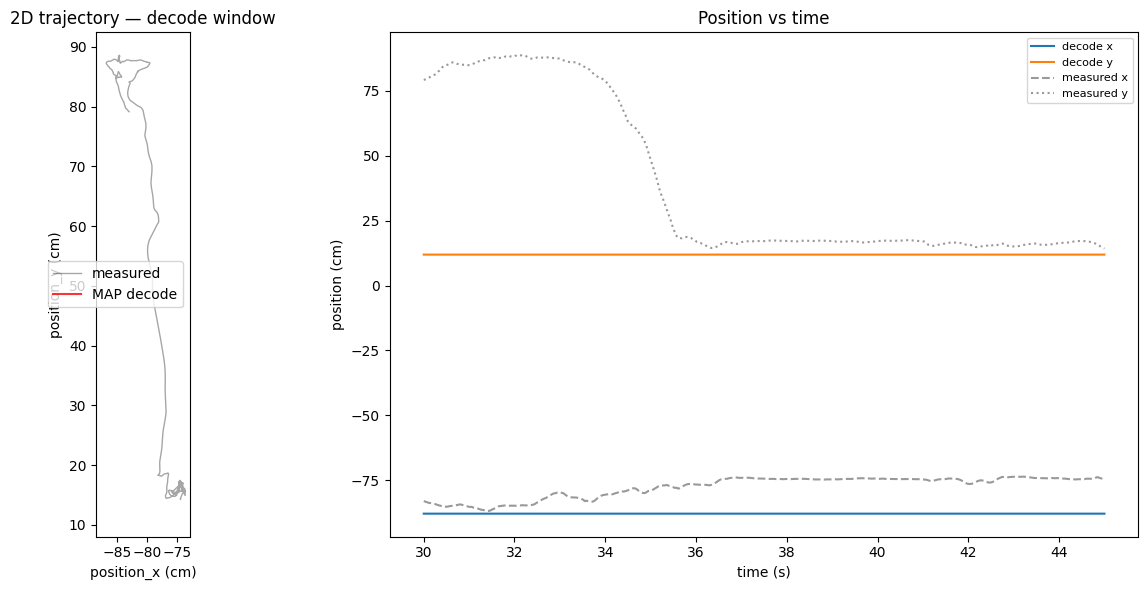

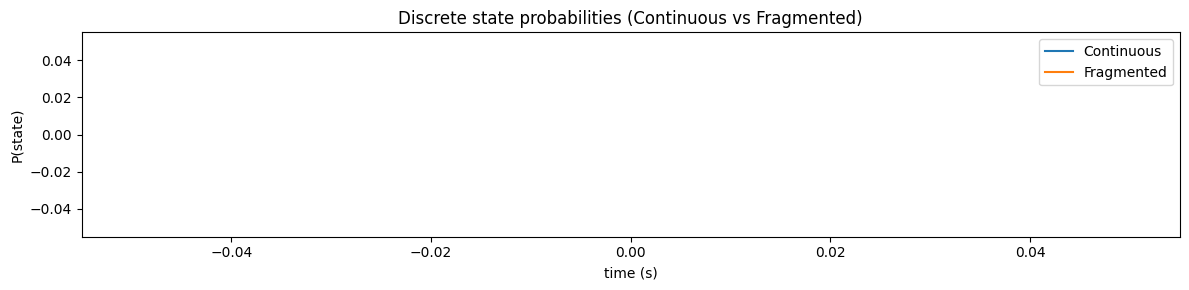

acausal_posterior shape: (7500, 5330)
marginal_log_likelihoods: nan


In [33]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_traj, ax_time = axes
ax_traj.plot(measured['position_x'], measured['position_y'], 'k-', alpha=0.35, linewidth=1, label='measured')
ax_traj.plot(x_map, y_map, 'r-', alpha=0.8, linewidth=1.5, label='MAP decode')
ax_traj.set_xlabel('position_x (cm)')
ax_traj.set_ylabel('position_y (cm)')
ax_traj.set_title('2D trajectory — decode window')
ax_traj.legend()
ax_traj.set_aspect('equal', adjustable='box')

ax_time.plot(decode_times, x_map, label='decode x')
ax_time.plot(decode_times, y_map, label='decode y')
if len(measured) > 0:
    ax_time.plot(measured.index, measured['position_x'], 'k--', alpha=0.4, label='measured x')
    ax_time.plot(measured.index, measured['position_y'], 'k:', alpha=0.4, label='measured y')
ax_time.set_xlabel('time (s)')
ax_time.set_ylabel('position (cm)')
ax_time.set_title('Position vs time')
ax_time.legend(fontsize=8)
plt.tight_layout()
plt.show()

if 'acausal_state_probabilities' in results:
    fig2, ax2 = plt.subplots(figsize=(12, 3))
    state_probs = results.acausal_state_probabilities
    for state_name in state_probs.states.values:
        ax2.plot(state_probs.time.values, state_probs.sel(states=state_name).values, label=str(state_name))
    ax2.set_xlabel('time (s)')
    ax2.set_ylabel('P(state)')
    ax2.set_title('Discrete state probabilities (Continuous vs Fragmented)')
    ax2.legend()
    plt.tight_layout()
    plt.show()

print('acausal_posterior shape:', results.acausal_posterior.shape)
if hasattr(results, 'attrs') and 'marginal_log_likelihoods' in results.attrs:
    print('marginal_log_likelihoods:', results.attrs['marginal_log_likelihoods'])

## Notes and troubleshooting

### Contrast with the existing RTC pipeline

The main RatS D4 notebook uses `ClusterlessRTCPositionDecoder` from `pyphoplacecellanalysis` (replay_trajectory_classification on PfND grids). This notebook uses Spyglass's **`ContFragClusterlessClassifier`** path instead — same underlying non_local_detector family, different integration and place-bin construction.

### All-NaN `acausal_posterior` or `ValueError: All-NaN slice encountered`

If MAP visualization fails with all-NaN posteriors, check `clusterless_events_to_spyglass_spike_lists`: **do not pad** spike lists to max electrode index with empty arrays. Electrodes with zero spikes in the encoding window produce NaN ground-process intensities that poison the entire likelihood. Only include electrodes that have spikes (compact list). Also use `nld_analysis.maximum_a_posteriori_estimate` on `acausal_posterior.unstack("state_bins").sum("state")` — not raw `argmax("state_bins")`, because exterior bins are intentionally NaN.

### Memory / full-maze decoding

Decoding the **full maze** at 500 Hz upsampling can be memory-heavy. Start with `USE_SHORT_TEST_WINDOW = True`, then expand only after a successful short run. See `Spike3D/EXTERNAL/DEVELOPER_NOTES/2026-06-30_MemoryAllocationIssue_in_clusterless_decoding.md`.

### Full Spyglass DataJoint workflow (not run here)

To use the official Spyglass pipeline end-to-end you would need:

1. NWB conversion of the Bapun session
2. Spyglass setup + MySQL database
3. Notebook 40 — clusterless waveform feature extraction (`UnitWaveformFeatures`)
4. Notebook 41 — `ClusterlessDecodingSelection` + `ClusterlessDecodingV1.populate()`

### Why we don't `import spyglass` here

Importing the `spyglass` package on a machine without a configured DataJoint database can prompt for a username/password. This notebook instead **mirrors** `ClusterlessDecodingV1._run_decoder` and `PositionGroup._upsample` inline using `non_local_detector` directly — same decoder logic, no DB connection.

### Read-only verification

This notebook intentionally never calls persistence APIs. After running, confirm no new `.nc` / `.pkl` files appeared under your Spyglass analysis dir and no session files were modified.

In [10]:
# Read-only sanity check — results exist only in kernel memory
assert isinstance(results, xr.Dataset)
assert 'acausal_posterior' in results
print('Read-only OK: results in memory only; no populate/save calls in this notebook.')

Read-only OK: results in memory only; no populate/save calls in this notebook.
